# Daşınmaz Əmlak Bazarının Analizi

Bu layihə çərçivəsində daşınmaz əmlak elanları üzərində geniş eksplorativ verilənlər analizi (EDA) aparılmışdır. İlk olaraq verilənlər bazası təmizlənmiş, çatışmayan dəyərlər tamamlanmış, dublikatlar aradan qaldırılmış və uyğun olmayan məlumatlar düzəldilmişdir. Daha sonra dəyişənlərin paylanması, outlier-lər və dəyişənlər arasındakı əlaqələr araşdırılmışdır. Layihənin sonunda isə əmlak qiymətinə təsir edə biləcək amillər, o cümlədən əmlak kateqoriyası, bina növü, sahə, m² qiyməti, məkan və digər xüsusiyyətlər müxtəlif vizuallaşdırmalar vasitəsilə təhlil edilmişdir. Aparılan analizlər verilənlər bazasını daha yaxşı anlamağa, qiymətə təsir edən əsas faktorları müəyyən etməyə və sonrakı mərhələdə qurulacaq maşın öyrənməsi modeli üçün etibarlı əsas formalaşdırmağa imkan vermişdir.

In [1]:
# Analiz və vizualizasiya üçün kitabxanaların yüklənməsi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

# Datasetin yüklənməsi
df=pd.read_csv('house_sale.csv',sep=',')

Saving house_sale.csv to house_sale (4).csv


# Datasetə ümumi baxış

In [3]:
df.head()
#ilk 5 sətir

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,...,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,...,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,...,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,...,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,...,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,...,15 / 16,3.0,100 m²,NaN,var,var,NaN,d71cf9a9-86dd-4162-b540-6252a8659a09,/items/4638863,Əhmədli m.* Xalqlar Dostluğu m.* Xətai r.* Əhm...


In [4]:
df.shape
#datasetin ölçüsü (sətir,sütun)

(100775, 51)

Dataset 51 sütundan və 100775 sətirdən ibarətdir.

# Sütun başlıqlarına və dəyərlərinə baxış

In [5]:
df.columns
#sütun başlıqlarına ümumi baxış

Index(['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price',
       'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x',
       'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale',
       'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y',
       'datetime_scrape_y', 'description', 'unit_price', 'total_price',
       'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title',
       'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y',
       'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə',
       'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka',
       'estate_details_id_y', 'estate_rel_url', 'extra_info'],
      dtype='object')

Datasetdə ümumi olaraq datalar azərbaycanca yazılıb, lakin bəzi sütun başlıqları ingiliscə adlandırılıb. Həmin sütun adlarını azərbaycanca yazıb datanı daha təmiz hala gətirməliyik. Amma əvvəlcə prosesi daha da aydınlaşdırmaq üçün sütunda "x" və "y" ilə fərqləndirilən sütunların eyni olub-olmamasını yoxlayaq.

In [6]:
id=(df['id_x'] == df['id_y']).all()
estate_rel_url=(df['estate_rel_url_x'] == df['estate_rel_url_y']).all()
datetime_scrape=(df['datetime_scrape_x'] == df['datetime_scrape_y']).all()
currency=(df['currency_x'] == df['currency_y']).all()
day=(df['day_x'] == df['day_y']).all()
hour=(df['hour_x'] == df['hour_y']).all()
details=(df['estate_details_id_x'] == df['estate_details_id_y']).all()

print(f"id: {id}")
print(f"estate_rel_url: {estate_rel_url}")
print(f"datetime_scrape: {datetime_scrape}")
print(f"currency: {currency}")
print(f"day: {day}")
print(f"hour: {hour}")
print(f"details: {details}")

id: False
estate_rel_url: True
datetime_scrape: False
currency: True
day: False
hour: False
details: True


Biraz daha araşdıraq:

In [7]:
df[['id_x','id_y','estate_rel_url_x','estate_rel_url_y','datetime_scrape_x','datetime_scrape_y','currency_x','currency_y','day_x','day_y','hour_x','hour_y','estate_details_id_x','estate_details_id_y']].head()

,id_x,id_y,estate_rel_url_x,estate_rel_url_y,datetime_scrape_x,datetime_scrape_y,currency_x,currency_y,day_x,day_y,hour_x,hour_y,estate_details_id_x,estate_details_id_y
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,/items/4521724,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,05.10.2024,23:52,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,92e82ea2-e1f3-4c2d-a284-151efd99281e
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,/items/4669294,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:56,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,505eaf81-6bc8-4094-9b00-aa82066548ee
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,/items/4669293,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:55,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,fa63b201-999d-43b5-a61a-778d9d79a6c6
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,/items/4647811,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:55,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,5db56980-05cc-4925-b55b-f58fb3f4d2b6
4,22d840df-9283-4112-bc71-7432511fc776,d71cf9a9-86dd-4162-b540-6252a8659a09,/items/4638863,/items/4638863,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:52,NaN,d71cf9a9-86dd-4162-b540-6252a8659a09,d71cf9a9-86dd-4162-b540-6252a8659a09


ID'lərin və tarixlərin fərqli olmasına əsasən deyə bilərik ki, əmlakın dataları fərqli günlərdə yenidən toplanaraq update olunub, ona görə də estate_rel_url və estate_details_id eyni qalır, currency isə sabit bir dəyərdir və True verir.

In [8]:
x=(df['estate_rel_url'] == df['estate_rel_url_x']).all()
y=(df['estate_rel_url'] == df['estate_rel_url_y']).all()

print(f"Əmlak_URL_1: {x}")
print(f"Əmlak_URL_2: {y}")

Əmlak_URL_1: True
Əmlak_URL_2: True


Son olaraq estate_rel_url sütununa baxırıq, bu 3 sütun ayrı-ayrılıqda eyni məlumatları saxlayır. Eyni sətirdə bir məlumat 3 yerdə təkrarlanır ona görə bu sütunlardan birini saxlayıb digərlərini silirik. Estate_details_is sütunu da duplicate sütun olduğuna görə birini silirik. Currency sütununa gəldikdə isə data azərbaycanca yazıldığına görə valyuta avtomatik olaraq AZN olur və sabit qalır, ona görə də duplicate sütun hesab olunmur.

In [9]:
df.drop(columns=['estate_rel_url_y', 'estate_rel_url','estate_details_id_y'], inplace=True)

Currency sütununa daha dərindən baxsaq:

In [10]:
(df['price'] == df['total_price']).all()

np.False_

Currency (valyuta) sütununun 2 yerdə fərqli adla aid olduğu price və total price bir-birindən fərqləndiyi üçün update olunmuş datada əmlakın qiymətinin dəyişdiyi müşahidə olunur, ona görə də currency sütunu olduğu kimi qalır.

Digər diqqət çəkən sütun isə city_when sütunudur. Çünki bu sütun city, day və hour olaraq ayrıca sütunlarda bölünüb və daha aydın şəkildə əks olunub. City hissəsi eyni qalsa da, when hissəsi ilkin tarixi göstərir (avtomatik olaraq bütün tarixlər "dünən" olaraq qeyd edilib) və update tarixini əks etdirməyərək conflict yaradır. Ona görə də city_when sütunu duplicate sütun hesab olunur və silinir.

In [11]:
df.drop(columns=['city_when'], inplace=True)

"bill_of_sale" sütunu "çıxarış" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun əmlakın çıxarışının olub-olmamasını əks etdirir. Sütunlara daha dəqiq baxsaq:

In [12]:
df['bill_of_sale'].value_counts(dropna=False)

,count
bill_of_sale,
Çıxarış var,79565
NaN,21210


In [13]:
df['Çıxarış'].value_counts(dropna=False)

,count
Çıxarış,
var,79565
yoxdur,21210


Dəyərlərə baxdıqda bill_of_sale sütununda "NaN" olaraq qeyd olunanların, Çıxarış sütununda "yoxdur" olaraq göstərildiyini görürük. Datanın daha təmiz olması üçün Çıxarış sütununu saxlayıb bill_of_sale sütununu silirik.

In [14]:
df.drop(columns=['bill_of_sale'], inplace=True)

Repair sütunu isə təmir sütununun ingiliscə adlandırılan versiyasıdır, hər iki sütun əmlakın təmirli olub-olmamasını göstərir. Sütunlara daha dəqiq baxsaq:

In [15]:
df['repair'].value_counts(dropna=False)

,count
repair,
Təmirli,81612
NaN,19163


In [16]:
df['Təmir'].value_counts(dropna=False)

,count
Təmir,
var,81612
yoxdur,13162
NaN,6001


Dəyərlərə baxdıqda repair sütununda "NaN" olaraq qeyd olunanların, Təmir sütununda "yoxdur" olaraq göstərildiyini görürük. Datanın daha təmiz olması üçün Təmir sütununu saxlayıb repair sütununu silirik.

In [17]:
df.drop(columns=['repair'], inplace=True)

Eyni şəkildə "mortgage" sütunu da "İpoteka" sütununun ingiliscə adlandırılmış halıdır və hər ikisi ipotekanın olub-olmamasını göstərir:

In [18]:
df['mortgage'].value_counts(dropna=False)

,count
mortgage,
NaN,67836
İpoteka var,32939


In [19]:
df['İpoteka'].value_counts(dropna=False)

,count
İpoteka,
NaN,67836
var,32939


Hər iki sütunda dəyərlər demək olar ki, eynidir. "mortgage" sütununu silib "İpoteka" sütununu saxlayırıq.

In [20]:
df.drop(columns=['mortgage'], inplace=True)

Duplicate sütunlar təmizləndikdən sonra sütun adlarını düzgün hala salaq.

In [21]:
df.rename(columns={
    'id_x': 'Elan_ID_1',
    'rel_url': 'Elan_URL',
    'estate_rel_url_x': 'Əmlak_URL',
    'datetime_scrape_x': 'Toplanma_tarixi_1',
    'price': 'Qiymət',
    'currency_x': 'Valyuta_1',
    'location': 'Məkan',
    'attributes': 'Əmlak_xüsusiyyətləri',
    'city': 'Şəhər',
    'day_x': 'Gün_1',
    'hour_x': 'Saat_1',
    'vip': 'VIP',
    'featured': 'Önə_çəkilmiş',
    'products_label': 'Elanı_yerləşdirən',
    'mortgage': 'İpoteka2',
    'img_url': 'Şəkil_URL',
    'id_y': 'Elan_ID_2',
    'estate_id': 'Əmlak_ID',
    'datetime_scrape_y': 'Toplanma_tarixi_2',
    'description': 'Təsvir',
    'unit_price': 'm²_qiyməti',
    'total_price': 'Ümumi_qiymət',
    'currency_y': 'Valyuta_2',
    'owner_name': 'Sahibin_adı',
    'owner_title': 'Sahibin_statusu',
    'shop_name': 'Agentliyin_adı',
    'shop_title': 'Agentliyin_növü',
    'address': 'Ünvan',
    'lat': 'Coğrafi_enlik',
    'lng': 'Coğrafi_uzunluq',
    'updated': 'Yenilənmə',
    'views': 'Baxış_sayı',
    'day_y': 'Gün_2',
    'hour_y': 'Saat_2',
    'estate_details_id_x': 'Detal_ID',
    'extra_info': 'Əlavə_məlumat',
    'Sahə': 'Sahə(m²)',
    'Torpaq sahəsi': 'Torpaq sahəsi(sot)'
}, inplace=True)

In [22]:
df.columns

Index(['Elan_ID_1', 'Elan_URL', 'Əmlak_URL', 'Toplanma_tarixi_1', 'Qiymət',
       'Valyuta_1', 'Məkan', 'Əmlak_xüsusiyyətləri', 'Şəhər', 'Gün_1',
       'Saat_1', 'VIP', 'Önə_çəkilmiş', 'Elanı_yerləşdirən', 'Şəkil_URL',
       'Elan_ID_2', 'Əmlak_ID', 'Toplanma_tarixi_2', 'Təsvir', 'm²_qiyməti',
       'Ümumi_qiymət', 'Valyuta_2', 'Sahibin_adı', 'Sahibin_statusu',
       'Agentliyin_adı', 'Agentliyin_növü', 'Ünvan', 'Coğrafi_enlik',
       'Coğrafi_uzunluq', 'Yenilənmə', 'Baxış_sayı', 'Gün_2', 'Saat_2',
       'Detal_ID', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı',
       'Sahə(m²)', 'Torpaq sahəsi(sot)', 'Təmir', 'Çıxarış', 'İpoteka',
       'Əlavə_məlumat'],
      dtype='object')

Sütunlar daha aydın şəkildə əks olundu.

# Data tiplərinin yoxlanılması

In [23]:
df.dtypes
#data tiplərinin yoxlanması

,0
Elan_ID_1,object
Elan_URL,object
Əmlak_URL,object
Toplanma_tarixi_1,object
Qiymət,float64
Valyuta_1,object
Məkan,object
Əmlak_xüsusiyyətləri,object
Şəhər,object
Gün_1,object


İlk öncə tarix sütunlarını "datetime" formatına çeviririk:

In [24]:
df['Toplanma_tarixi_1'] = (
    pd.to_datetime(df['Toplanma_tarixi_1'], format='mixed', utc=True)
      .dt.tz_localize(None)
)

In [25]:
df['Toplanma_tarixi_2'] = (
    pd.to_datetime(df['Toplanma_tarixi_2'], format='mixed', utc=True)
      .dt.tz_localize(None)
)

In [26]:
for col in ['Gün_1', 'Gün_2']:
    df[col] = pd.to_datetime(df[col], format='%d.%m.%Y')

In [27]:
for col in ['Saat_1', 'Saat_2']:
    df[col] = pd.to_datetime(df[col], format='%H:%M')

Otaq sayı sütunu "float" olaraq verilib, lakin "int" tipində olmalıdır. Otaq sayı natural ədəd olduğu üçün onu int tipinə çevirək:

In [28]:
df['Otaq sayı'] = df['Otaq sayı'].astype('Int64')

Sahə sütunu "object" olaraq verilib, bunun səbəbi sahələrin "m²" ilə birlikdə yazılmasıdır, sütunu "float" tipinə çevirək:

In [29]:
df['Sahə(m²)'] = np.where(
    df['Sahə(m²)'].str.contains('sot', case=False, na=False),
    df['Sahə(m²)'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float) * 100,
    df['Sahə(m²)'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)
)

Sahə sütununu "float" tipinə çevirmək üçün m² hissələrini kəsərkən sahə sütununda "sot" ifadəsinin də yer aldığını müşahidə etdik və sot=100 m² olduğunu nəzərə alaraq sot ilə ifadə olunan sahələri m²-a çevirib sonra float tipinə çevirdik.

Torpaq sahəsi sütunu "object" olaraq verilib, bunun səbəbi torpaq sahəsinin "sot" ifadəsi ilə birlikdə verilməsidir, sütunu "float" tipinə çevirək:

In [30]:
df['Torpaq sahəsi(sot)'] = (
    df['Torpaq sahəsi(sot)']
    .str.replace(' sot', '', regex=False)
    .astype('float')
)

Torpaq sahəsi sütunundakı "sot" ifadəsini kəsib float tipinə çevirdik.

In [31]:
df['m²_qiyməti'] = (
    df['m²_qiyməti']
    .str.replace(' AZN/m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

m²_qiyməti sütunu yanında yazılan "AZN/m²" ifadəsinə görə "object" tipində verilmişdi, bu ifadəni kəsib "float" tipinə çevirdik.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Elan_ID_1             100775 non-null  object        
 1   Elan_URL              100775 non-null  object        
 2   Əmlak_URL             100775 non-null  object        
 3   Toplanma_tarixi_1     100775 non-null  datetime64[ns]
 4   Qiymət                100775 non-null  float64       
 5   Valyuta_1             100775 non-null  object        
 6   Məkan                 100775 non-null  object        
 7   Əmlak_xüsusiyyətləri  100775 non-null  object        
 8   Şəhər                 100775 non-null  object        
 9   Gün_1                 100775 non-null  datetime64[ns]
 10  Saat_1                100775 non-null  datetime64[ns]
 11  VIP                   8596 non-null    object        
 12  Önə_çəkilmiş          3149 non-null    object        
 13 

Bütün data tipləri düzgün hala gətirildi.

# Dublikatların yoxlanılması

In [33]:
df.duplicated().sum()
#dublikat dəyərlərin yoxlanması

np.int64(0)

In [34]:
df['Əmlak_ID'].duplicated().sum()

np.int64(0)

Heçbir dublikat sətir yoxdur.

# Boş dəyərlərin yoxlanması və idarə olunması

In [35]:
df.isnull().mean()*100
#null (boş) dəyərlərin yoxlanması

,0
Elan_ID_1,0.000000
Elan_URL,0.000000
Əmlak_URL,0.000000
Toplanma_tarixi_1,0.000000
Qiymət,0.000000
Valyuta_1,0.000000
Məkan,0.000000
Əmlak_xüsusiyyətləri,0.000000
Şəhər,0.000000
Gün_1,0.000000


Boş dəyərləri müvafiq olaraq dolduraq və ya əvəz edək:

## `VIP` sütunu

In [36]:
df['VIP'].value_counts(dropna=False)

,count
VIP,
NaN,92179
vipped,8596


bill_of_sales sütununu sildikdə müşahidə etdik ki, çıxarışı olan əmlaklar qeyd olunub, olmayanlar isə NaN olub. Bunun səbəbi data toplanarkən çıxarışı olanların qeyd olunması, çıxarışı olmayanların isə boş saxlanılmasıdır. VIP və Çıxarış dəyişənləri ikili (binary) kateqorik dəyişənlərdir. Ona görə də vip elanlar qeyd olunub olmayanlar NaN olaraq düşüb.

In [37]:
df['VIP'] = df['VIP'].eq('vipped').astype(int)

In [38]:
df['VIP'].value_counts(dropna=False)

,count
VIP,
0,92179
1,8596


NaN dəyərləri 0 (vip olmayan və ya normal elan) olaraq doldurduq, boş dəyərlər 0-la əvəz olundu.

## `Önə_çəkilmiş` sütunu

In [39]:
df['Önə_çəkilmiş'].value_counts(dropna=False)

,count
Önə_çəkilmiş,
NaN,97626
featured,3149


VIP sütununda olduğu kimi Önə_çəkilmiş sütunundakı dəyişənlər də binary kateqorik dəyişənlərdir. Çünki 2 seçim var: ya elan önə çəkilir (elan siyahısında daha yuxarı və ya xüsusi bölmədə göstərilir) ya da normal elan olur.

In [40]:
df['Önə_çəkilmiş'] = df['Önə_çəkilmiş'].eq('featured').astype(int)

In [41]:
df['Önə_çəkilmiş'].value_counts(dropna=False)

,count
Önə_çəkilmiş,
0,97626
1,3149


NaN dəyərləri 0 (önə çəkilməmiş və ya normal elan) olaraq doldurduq, boş dəyərlər 0-la əvəz olundu.

## `Binanın növü` sütunu

In [42]:
df['Binanın növü'].value_counts(dropna=False)

,count
Binanın növü,
NaN,100621
Ev / Mənzil,85
Biznes mərkəzi,64
Villa,5


NaN dəyərləri mümkün qədər azaltmağa çalışırıq, bunun üçün əvvəlcə kateqoriya sütunundan istifadə edirik. Ev/Mənzil bina növünə əsasən mənzil çoxmərtəbəli binada yerləşən yaşayış sahəsi olduğu üçün Həyət evi/Bağ evi kateqoriyasına aid bina növündəki dəyərləri (NaN) villa olaraq əvəz edirik:

In [43]:
mask = (
    df['Binanın növü'].isna() &
    (df['Kateqoriya'] == 'Həyət evi/Bağ evi')
)

df.loc[mask, 'Binanın növü'] = 'Villa'

In [44]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
NaN,85050
Villa,15576
Ev / Mənzil,85
Biznes mərkəzi,64


Kateqoriya sütunundan yenidən istifadə edərək "obyekt" kateqoriyasına aid bina növlərini (NaN olanları) "Biznes mərkəzi" olaraq əvəz edirik:

In [45]:
mask = (
    df['Binanın növü'].isna() &
    (df['Kateqoriya'] == 'Obyekt')
)

df.loc[mask, 'Binanın növü'] = 'Biznes mərkəzi'

In [46]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
NaN,81004
Villa,15576
Biznes mərkəzi,4110
Ev / Mənzil,85


Növbəti mərhələdə otaq sayına əsasən boş dəyərləri doldururuq:

In [47]:
df.loc[df['Binanın növü'] == 'Ev / Mənzil', 'Otaq sayı'].max()

np.int64(15)

In [48]:
df.loc[df['Binanın növü'] == 'Ev / Mənzil', 'Otaq sayı'].mean()

np.float64(4.588235294117647)

In [49]:
df.loc[df['Binanın növü'] == 'Biznes mərkəzi', 'Otaq sayı'].max()

np.int64(20)

In [50]:
df.loc[df['Binanın növü'] == 'Biznes mərkəzi', 'Otaq sayı'].mean()

np.float64(6.328125)

Ev / Mənzil və Biznes mərkəzi üçün dəyərləri tamamlayırıq. Hər iki bina növü üçün max və mean dəyərlər araşdırılır və alınan nəticələrə əsasən boş dəyərlər müvafiq olaraq doldurulur:

In [51]:
mask = df['Binanın növü'].isna()

df.loc[
    mask & (df['Otaq sayı'] >= 15),
    'Binanın növü'
] = 'Biznes mərkəzi'

df.loc[
    mask & (df['Otaq sayı'] < 15),
    'Binanın növü'
] = 'Ev / Mənzil'

In [52]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
Ev / Mənzil,76076
Villa,15576
NaN,5008
Biznes mərkəzi,4115


Qalan boş dəyərləri "Digər" olaraq doldururuq:

In [53]:
df['Binanın növü'] = df['Binanın növü'].fillna('Digər')

In [54]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
Ev / Mənzil,76076
Villa,15576
Digər,5008
Biznes mərkəzi,4115


Bütün boş dəyərlər müvafiq olaraq dolduruldu.

## `Mərtəbə` sütunu

In [55]:
df['Mərtəbə'].isna().value_counts()

,count
Mərtəbə,
False,75996
True,24779


False → Mərtəbə məlumatı var.

True → Mərtəbə məlumatı yoxdur (NaN).

In [56]:
df['Mərtəbə'] = df['Mərtəbə'].fillna('Məlum deyil')

Mərətəbə sütunundakı boş dəyərləri doldurmaq üçün hər hansı qanunauyğunluq mövcud deyil, ona görə də "məlum deyil" olaraq əvəz edirik.

## `İpoteka` sütunu

In [57]:
df['İpoteka'].value_counts(dropna=False)

,count
İpoteka,
NaN,67836
var,32939


İpoteka sütunundakı dəyişənlər də binary kateqorik dəyişənlərdir. Ona görə də NaN olan dəyərləri "yoxdur" ilə əvəz edirik:

In [58]:
df['İpoteka'] = df['İpoteka'].fillna('yoxdur')

## `Elanı_yerləşdirən` sütunu

In [59]:
df['Elanı_yerləşdirən'].value_counts(dropna=False)

,count
Elanı_yerləşdirən,
Agentlik,71981
NaN,28145
Kompleks,649


Elanı_yerləşdirən sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.

In [60]:
df['Elanı_yerləşdirən'] = df['Elanı_yerləşdirən'].fillna('Məlum deyil')

## `Saat_2` sütunu

In [61]:
df['Saat_2'].isna().value_counts(dropna=False)

,count
Saat_2,
True,85144
False,15631


False → Saat məlumatı var.

True → Saat məlumatı yoxdur (NaN).

Saat_2 sütunu əmlakın update olunmuş məlumatlarının daxil edildiyi saatlardır. Bu məlumatları silmək bizə heç bir data itkisi yaratmır, çünki analiz zamanı məlumatların update olunmuş halını istifadə edirik, nə vaxt update olunduğu önəmli data deyil.

In [62]:
df.drop(columns=['Saat_2'], inplace=True)

## `Təsvir` sütunu

In [63]:
df['Təsvir'].isna().value_counts(dropna=False)

,count
Təsvir,
False,100510
True,265


False → Təsvir məlumatı var.

True → Təsvir məlumatı yoxdur (NaN).

Təsvir sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Əlavə olunmayıb" olaraq əvəz edirik.

In [64]:
df['Təsvir'] = df['Təsvir'].fillna('Əlavə olunmayıb')

## `m²_qiyməti` sütunu

In [65]:
df['m²_qiyməti'].isna().value_counts(dropna=False)

,count
m²_qiyməti,
False,75996
True,24779


False → m² qiyməti məlumatı var.

True → m² qiyməti məlumatı yoxdur (NaN).

Boş dəyərləri m² qiyməti = Ümumi qiymət / Sahə(m²) istifadə edərək doldururuq:

In [66]:
mask = df['m²_qiyməti'].isna()

df.loc[mask, 'm²_qiyməti'] = (
    df.loc[mask, 'Ümumi_qiymət'] /
    df.loc[mask, 'Sahə(m²)']
)

## `Torpaq sahəsi(sot)` sütunu

In [67]:
df['Torpaq sahəsi(sot)'].isna().value_counts(dropna=False)

,count
Torpaq sahəsi(sot),
True,85204
False,15571


False → Torpaq sahəsi məlumatı var.

True → Torpaq sahəsi məlumatı yoxdur (NaN).

Torpaq sahəsi(sot) sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.

In [68]:
df['Torpaq sahəsi(sot)'] = (df['Torpaq sahəsi(sot)'].astype('object').fillna('Məlum deyil'))

Sütun float data tipində idi, "məlum deyil" ilə əvəz etmək üçün əvvəlcə data tipini object etdik, sonra isə boş dəyərləri doldurduq.

## `Sahibin_adı` sütunu

In [69]:
df['Sahibin_adı'].isna().value_counts(dropna=False)

,count
Sahibin_adı,
False,100118
True,657


False → Sahibin adı məlumatı var.

True → Sahibin adı məlumatı yoxdur (NaN).

Sahibin adı sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.

In [70]:
df['Sahibin_adı'] = (df['Sahibin_adı'].fillna('Məlum deyil'))

## `Sahibin_statusu` sütunu

In [71]:
df['Sahibin_statusu'].value_counts(dropna=False)

,count
Sahibin_statusu,
vasitəçi (agent),89733
mülkiyyətçi,10385
NaN,657


Sahibin statusu sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Digər" olaraq əvəz edirik.

In [72]:
df['Sahibin_statusu'] = (df['Sahibin_statusu'].fillna('Digər'))

## `Agentliyin_adı` sütunu

In [73]:
df['Agentliyin_adı'].isna().value_counts(dropna=False)

,count
Agentliyin_adı,
False,72018
True,28757


False → Agentliyin adı məlumatı var.

True → Agentliyin adı məlumatı yoxdur (NaN).

Agentliyin adı sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.




In [74]:
df['Agentliyin_adı'] = (df['Agentliyin_adı'].fillna('Məlum deyil'))

## `Agentliyin_növü` sütunu

In [75]:
df['Agentliyin_növü'].value_counts(dropna=False)

,count
Agentliyin_növü,
Daşınmaz əmlak agentliyi,72018
NaN,28757


Agentliyin növü sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Digər" olaraq əvəz edirik.

In [76]:
df['Agentliyin_növü'] = (df['Agentliyin_növü'].fillna('Digər'))

## `Təmir` sütunu

In [77]:
df['Təmir'].value_counts(dropna=False)

,count
Təmir,
var,81612
yoxdur,13162
NaN,6001


Təmir sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.

In [78]:
df['Təmir'] = (df['Təmir'].fillna('Məlum deyil'))

## `Otaq sayı` sütunu

In [79]:
df['Otaq sayı'].isna().value_counts(dropna=False)

,count
Otaq sayı,
False,91363
True,9412


False → Təmir məlumatı var.

True → Təmir məlumatı yoxdur (NaN).

Otaq sayı sütunundakı boş dəyərləri doldurmaq üçün hər hansı əlavə məlumat yoxdur, ona görə də "Məlum deyil" olaraq əvəz edirik.

In [80]:
df['Otaq sayı'] = (df['Otaq sayı'].astype('object').fillna('Məlum deyil'))

In [81]:
df.isnull().sum()

,0
Elan_ID_1,0
Elan_URL,0
Əmlak_URL,0
Toplanma_tarixi_1,0
Qiymət,0
Valyuta_1,0
Məkan,0
Əmlak_xüsusiyyətləri,0
Şəhər,0
Gün_1,0


Bütün boş dəyərlər dolduruldu.

# Outlierlərin araşdırılması və işlənməsi

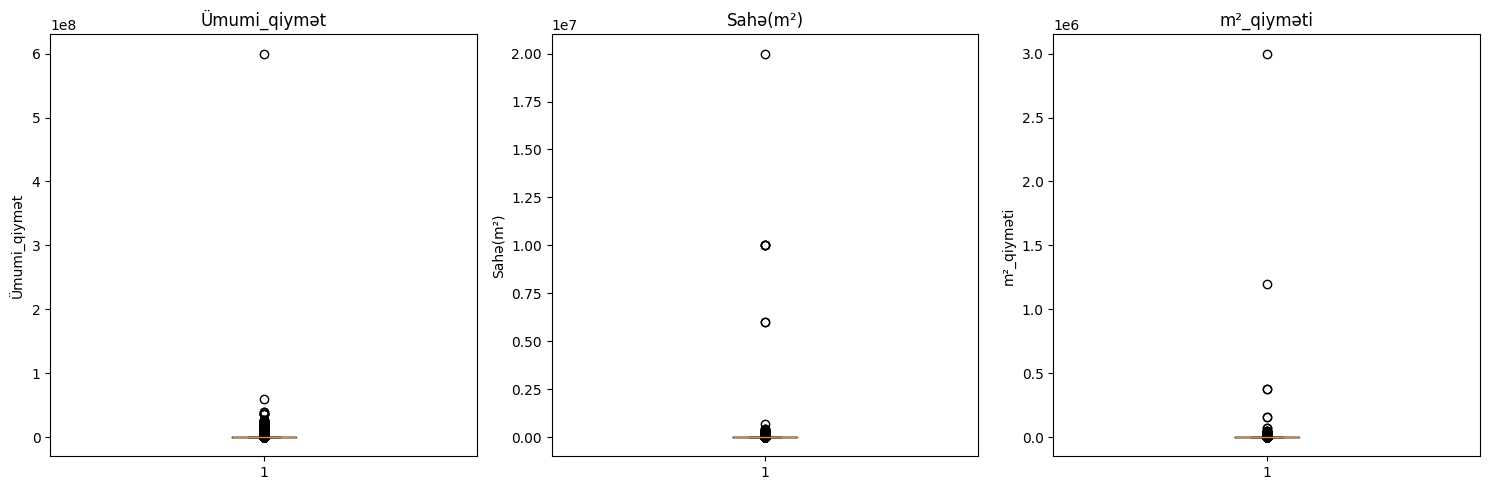

In [82]:
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, columns):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## `Ümumi qiymət`

In [83]:
Q1 = df['Ümumi_qiymət'].quantile(0.25)
Q3 = df['Ümumi_qiymət'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Aşağı sərhəd: {lower}")
print(f"Yuxarı sərhəd: {upper}")

Aşağı sərhəd: -144500.0
Yuxarı sərhəd: 627500.0


627 500 AZN-dən yuxarı olan bütün elanlar IQR metoduna görə outlier hesab olunur. Aşağı sərhəd mənfi çıxdığı üçün aşağı tərəfdə outlier yoxdur (qiymət mənfi ola bilməz).

Outlierlərin sayına baxaq:

In [84]:
price_outliers = df[df['Ümumi_qiymət'] > 627500]
print(price_outliers.shape)

(7322, 43)


Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq ümumi qiymət üzrə təxminən 7% outlier dəyər mövcuddur.

Outlier dəyərlərə daha yaxından baxaq:

In [85]:
price_outliers[['Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Sahə(m²)']].head(20)

,Ümumi_qiymət,Kateqoriya,Binanın növü,Sahə(m²)
5,650000.0,Köhnə tikili,Ev / Mənzil,130.0
8,3000000.0,Obyekt,Biznes mərkəzi,485.0
10,1050000.0,Obyekt,Biznes mərkəzi,360.0
20,770000.0,Yeni tikili,Ev / Mənzil,230.6
27,680000.0,Yeni tikili,Ev / Mənzil,260.0
35,1550000.0,Torpaq,Digər,5030.0
105,640000.0,Həyət evi/Bağ evi,Villa,260.0
106,780000.0,Həyət evi/Bağ evi,Villa,450.0
109,680000.0,Həyət evi/Bağ evi,Villa,300.0
120,850000.0,Obyekt,Biznes mərkəzi,150.0


Ümumi olaraq baxdıqda yüksək qiymətli əmlakların yeni tikililər, villalar, kommersiya obyektləri və ya böyük torpaq sahələri olduğu müşahidə olunur. Birazda araşdıraq:

In [86]:
df.nlargest(10,'Ümumi_qiymət')[['Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Sahə(m²)']]

,Ümumi_qiymət,Kateqoriya,Binanın növü,Sahə(m²)
6605,600000000.0,Yeni tikili,Ev / Mənzil,200.0
6942,60000000.0,Yeni tikili,Ev / Mənzil,50.0
45825,40000000.0,Torpaq,Digər,20000000.0
72637,39000000.0,Torpaq,Digər,20000.0
8065,36000000.0,Obyekt,Biznes mərkəzi,3000.0
31276,36000000.0,Obyekt,Biznes mərkəzi,3000.0
34851,36000000.0,Obyekt,Biznes mərkəzi,3000.0
81161,36000000.0,Obyekt,Biznes mərkəzi,3000.0
69308,26000000.0,Torpaq,Digər,6000000.0
84337,26000000.0,Torpaq,Digər,130000.0


600 milyon AZN, 200 m² mənzil → sahə kiçik, qiymət böyük.

60 milyon AZN, 50 m² mənzil → sahə kiçik, qiymət böyük.

Digər 40 milyon AZN, 20 milyon m² əmlakı sahənin outlierlərini hesablayanda araşdırılacaq. İndi isə bu iki outlieri daha da dərindən araşdıraq:

In [87]:
df.loc[
    df['Ümumi_qiymət'].isin([600000000, 60000000]),
    ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti', 'Kateqoriya', 'Təsvir']
]

,Ümumi_qiymət,Sahə(m²),m²_qiyməti,Kateqoriya,Təsvir
6605,600000000.0,200.0,3000000.0,Yeni tikili,Əlavə olunmayıb
6942,60000000.0,50.0,1200000.0,Yeni tikili,Dom


200 m² yeni tikili mənzilin 600 milyon AZN olması bazar reallığı ilə uyğun gəlmir. 50 m² mənzilin 60 milyon AZN olması da eyni dərəcədə qeyri-realdır.
m² qiymətləri də (3 000 000 və 1 200 000 AZN/m²) bazardakı normal diapazondan çox uzaqdır. Təsvirlər də çox informativ deyil ("Əlavə olunmayıb", "Dom"), bu da məlumatın etibarlılığına əlavə dəstək vermir.

In [88]:
df = df[~df['Ümumi_qiymət'].isin([600000000, 60000000])]

200 m² sahəsi olan mənzilin 600 milyon AZN və 50 m² sahəsi olan mənzilin 60 milyon AZN qiymətlə təqdim edildiyi elanlar məlumat xətası kimi qiymətləndirilmiş və datasetdən çıxarılmışdır. Digər yüksək qiymətli elanlar isə villa, iri torpaq sahəsi və kommersiya obyektlərinə aid olduğundan saxlanılmışdır.

## `Sahə(m²)`

In [89]:
Q1 = df['Sahə(m²)'].quantile(0.25)
Q3 = df['Sahə(m²)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Aşağı sərhəd:", lower)
print("Yuxarı sərhəd:", upper)

Aşağı sərhəd: -65.0
Yuxarı sərhəd: 295.0


295 m²-dan yuxarı olan bütün elanlar IQR metoduna görə outlier hesab olunur. Aşağı sərhəd mənfi çıxdığı üçün aşağı tərəfdə outlier yoxdur (sahə mənfi ola bilməz).

In [90]:
price_outliers = df[df['Sahə(m²)'] > 295]
print(price_outliers.shape)

(10265, 43)


Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq sahə üzrə təxminən 10% outlier dəyər mövcuddur.

In [91]:
df.nlargest(10,'Sahə(m²)')[['Sahə(m²)', 'Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Məkan']]

,Sahə(m²),Ümumi_qiymət,Kateqoriya,Binanın növü,Məkan
45825,20000000.0,40000000.0,Torpaq,Digər,28 May m.
4736,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
9746,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
21517,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
75857,10000000.0,3000.0,Torpaq,Digər,Fatmayı q.
28995,6000000.0,19000000.0,Torpaq,Digər,Binəqədi r.
69308,6000000.0,26000000.0,Torpaq,Digər,Binəqədi r.
172,700000.0,80000.0,Torpaq,Digər,Maştağa q.
87428,440000.0,2640000.0,Torpaq,Digər,Qobu q.
3348,400000.0,3500.0,Torpaq,Digər,Buzovna q.


20 000 000 m² sahə,	40 000 000 AZN 	→ 20 milyon m² (2000 hektar) çox böyük sahədir.

10 000 000 m² sahə,	2 500	AZN → 10 milyon m² torpağın cəmi 2500 AZN olması iqtisadi baxımdan real deyil.

10 000 000 m² sahə,	3 000	AZN →  10 milyon m² torpağın cəmi 3000 AZN olması iqtisadi baxımdan real deyil.

6 000 000 m² sahə,	19 000 000 AZN	→ 6 milyon m² (600 hektar) çox böyük sahədir.

6 000 000	m² sahə, 26 000 000	AZN →  6 milyon m² (600 hektar) çox böyük sahədir.

400 000 m² sahə, 3500 AZN	→ 400 000 m² torpağın 3500 AZN olması iqtisadi baxımdan real deyil.

Sahəsi böyük olan sütunların reallığı araşdırılmalıdır, amma digərləri iqtisadi baxımdan doğru hesab olunmadığı üçün silinəcək.

In [92]:
df.loc[df['Sahə(m²)'].isin([20000000, 6000000]),['Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,Sahə(m²),Ümumi_qiymət,Təsvir
28995,6000000.0,19000000.0,Binəqədi rayonunda 6 hektar torpaq sahəsisatil...
45825,20000000.0,40000000.0,Torpaq 2 hektardi sehere denize gozel menzeres...
69308,6000000.0,26000000.0,Binəqədi rayonunda 6 hektar torpaq sahəsisatil...


Təsvir sütununa diqqət etdikdə görürük ki, sahələr hektarla verilib 1 hektar = 10 000 m² olduğunu nəzərə alsaq sahə sütununda göstərilən dəyər ilə təsvirdəki dəyərdə məlumat uyğunsuzluğu var. Onları tam düzgün versiyaya gətirək və outlierləri bərpa edək:

In [93]:
# 1 hektar = 10 000 m²
df['Sahə(m²)'] = df['Sahə(m²)'].replace({
    6000000: 60000,
    20000000: 20000
})

Digər outlier hesab etdiyimiz dəyərləri də bu qayda ilə araşdıraq:

In [94]:
df.nlargest(10,'Sahə(m²)')[['Sahə(m²)', 'Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Məkan','Təsvir']]

,Sahə(m²),Ümumi_qiymət,Kateqoriya,Binanın növü,Məkan,Təsvir
4736,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
9746,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
21517,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
75857,10000000.0,3000.0,Torpaq,Digər,Fatmayı q.,…\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi q...
172,700000.0,80000.0,Torpaq,Digər,Maştağa q.,Salam..Ərazi magistral yolda yerləşir...məktəb...
87428,440000.0,2640000.0,Torpaq,Digər,Qobu q.,Abşeron Rayonu Qobu Qesebesi Sevil Massivi.\n4...
3348,400000.0,3500.0,Torpaq,Digər,Buzovna q.,"Çox təcili və dəyərindən ucuz qiymətə 4,2hek..."
37618,400000.0,16000000.0,Torpaq,Digər,Lökbatan q.,⛔️ XAHİŞ OLUNUR VASİTƏÇİLƏR NARAHAT ETMƏSİNLƏR...
75936,350000.0,30000.0,Torpaq,Digər,Xaçmaz,Torpaqin sənətləri tamdır ekin ve baq ucun elv...
99064,340000.0,11000000.0,Torpaq,Digər,Binəqədi q.,Binəqədi əsas yolun kənarında yerləşir\nSənədl...


Araşdırdıqda yenə məlumat uyğunsuzluğu olduğunu müşahidə edirik, hektarları düzgün şəkildə çevirək:

In [95]:
# 1 hektar = 10 000 m²
df.loc[[4736, 9746, 21517, 75857], 'Sahə(m²)'] = 10000

df.loc[3348, 'Sahə(m²)'] = 42000

Outlier dəyərləri araşdırarkən bu dəyərlərin əslində səhv çevrilmiş sahə sütunundan irəli gəldiyi aşkar edildi. Təsvir sütunundakı məlumatlara əsasən hektarla ifadə olunan dəyəri sahəyə çevirərək outlier dəyərləri bərpa etdik.

## `m²_qiyməti`

In [96]:
Q1 = df['m²_qiyməti'].quantile(0.25)
Q3 = df['m²_qiyməti'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Aşağı sərhəd:", lower)
print("Yuxarı sərhəd:", upper)

Aşağı sərhəd: 97.07317073170702
Yuxarı sərhəd: 4309.756097560976


97 AZN/m²-dan yuxarı olan bütün elanlar IQR metoduna görə aşağı outlier, 4309 AZN/m²-dən yuxarı olanlar isə yüksək outlier hesab olunur.

Outlierlərin sayına baxaq:

In [97]:
price_outliers = df[
    (df['m²_qiyməti'] < 97) |
    (df['m²_qiyməti'] > 4309)
]

price_outliers.shape

(5238, 43)

Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq sahə üzrə təxminən 5% outlier dəyər mövcuddur.

In [98]:
df.nlargest(10, 'm²_qiyməti')[['m²_qiyməti', 'Ümumi_qiymət', 'Sahə(m²)', 'Kateqoriya', 'Binanın növü', 'Məkan']]

,m²_qiyməti,Ümumi_qiymət,Sahə(m²),Kateqoriya,Binanın növü,Məkan
12285,380000.000000,380000.0,1.0,Həyət evi/Bağ evi,Villa,Şüvəlan q.
16168,380000.000000,380000.0,1.0,Həyət evi/Bağ evi,Villa,Şüvəlan q.
9096,159482.758621,18500000.0,116.0,Obyekt,Biznes mərkəzi,Sahil m.
14281,159482.758621,18500000.0,116.0,Obyekt,Biznes mərkəzi,Sahil m.
11364,72222.222222,650000.0,9.0,Həyət evi/Bağ evi,Villa,Azadlıq Prospekti m.
15638,72222.222222,650000.0,9.0,Həyət evi/Bağ evi,Villa,Azadlıq Prospekti m.
34426,51020.408163,5000000.0,98.0,Obyekt,Biznes mərkəzi,Sahil m.
98699,51020.408163,5000000.0,98.0,Obyekt,Biznes mərkəzi,Sahil m.
75798,51000.000000,5100000.0,100.0,Obyekt,Biznes mərkəzi,Sahil m.
98693,49494.949495,4900000.0,99.0,Obyekt,Biznes mərkəzi,Sahil m.


In [99]:
df.loc[df['m²_qiyməti'].isin([380000]),['m²_qiyməti', 'Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,m²_qiyməti,Sahə(m²),Ümumi_qiymət,Təsvir
12285,380000.0,1.0,380000.0,Salam Suvalanda Esas yola Yaxin 4 Sot Moderin ...
16168,380000.0,1.0,380000.0,Salam Suvalanda Esas yola Yaxin 4 Sot Moderin ...


Təsvir sütununa baxdıqda torpağın 4 sot qeyd olunduğunu görürük, sahə sütunu ilə təsvir sütunu arasında məlumat uyğunsuzluğu var. Uyğunsuzluğu aradan qaldıraq:

In [100]:
# 1 ot = 100 m²
df.loc[[16168,12285], 'Sahə(m²)'] = 400.0

In [101]:
df.loc[[16168, 12285], 'Sahə(m²)'] = 400

df.loc[[16168, 12285], 'm²_qiyməti'] = (
    df.loc[[16168, 12285], 'Ümumi_qiymət'] /
    df.loc[[16168, 12285], 'Sahə(m²)']
)

Həm sahənin qiymətini, həm də m²_qiymətini də ayrıca sahəyə uyğun dəyişdik.



In [102]:
df.loc[df['Sahə(m²)'].isin([9.0]),['m²_qiyməti', 'Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,m²_qiyməti,Sahə(m²),Ümumi_qiymət,Təsvir
11364,72222.222222,9.0,650000.0,"Binəqədi r-nu , RƏSULZADƏ qəsəbəsi,AZADLIQ met..."
15638,72222.222222,9.0,650000.0,"Binəqədi r-nu , RƏSULZADƏ qəsəbəsi,AZADLIQ met..."
68330,3280.000000,9.0,29500.0,Mikro-mənzil satılır!!! -Bina.\nArtıq dünyanın...


Təsvir sütununa baxdıqda torpağın 9 sot qeyd olunduğunu görürük, sahə sütunu ilə təsvir sütunu arasında məlumat uyğunsuzluğu var. Uyğunsuzluğu aradan qaldıraq:

In [103]:
# 1 ot = 100 m²
df.loc[[11364,15638], 'Sahə(m²)'] = 900

In [104]:
df.loc[[11364,15638], 'm²_qiyməti'] = (
    df.loc[[11364,15638], 'Ümumi_qiymət'] /
    df.loc[[11364,15638], 'Sahə(m²)']
)

Həm sahənin qiymətini, həm də m²_qiymətini də ayrıca sahəyə uyğun dəyişdik.

Outlier dəyərləri araşdırarkən bu dəyərlərin əslində səhv çevrilmiş sahə sütunundan irəli gəldiyi aşkar edildi. Təsvir sütunundakı məlumatlara əsasən sotla ifadə olunan dəyəri sahəyə çevirdik və m²_qiymətini buna uyğunlaşdıraraq outlier dəyərləri bərpa etdik.

# Feature Engineering

## `Qiymət_kateqoriyası` sütunu

Əmlakların qiymətlərinə əsasən onları kateqoriyalara ayıraq: Büdcə, Orta, Lüks, Premium.

In [105]:
df['Ümumi_qiymət'].describe()

,Ümumi_qiymət
count,1.007730e+05
mean,3.358127e+05
std,7.541224e+05
min,1.100000e+01
25%,1.450000e+05
50%,2.180000e+05
75%,3.380000e+05
max,4.000000e+07


**Min ->** 11 000

**25% (Q1) ->** 	145 000

**50% (Median, Q2)->** 	218 000

**75% (Q3)->**  	338 000

**Max->**  40 000 000

Kvartillərdən istifadə edərək qiymət aralıqlarını müəyyənləşdirdikdən sonra buna əsasən yeni sütunu yaradırıq.

In [106]:
df['Qiymət_kateqoriyası'] = pd.cut(
    df['Ümumi_qiymət'],
    bins=[0, 145000, 218000, 338000, float('inf')],
    labels=['Büdcə', 'Orta', 'Premium', 'Lüks'],
    include_lowest=True
)

## `Sahə_kateqoriyası` sütunu

Əmlakın əhatə etdiyi sahəyə əsasən onu kateqoriyalara ayıraq: Kiçik, Orta, Böyük, Çox böyük.

In [107]:
df['Sahə(m²)'].describe()

,Sahə(m²)
count,100773.000000
mean,411.862747
std,5766.348697
min,4.000000
25%,70.000000
50%,105.000000
75%,160.000000
max,700000.000000


**Min ->** 4 m²

**25% (Q1) ->** 	70 m²

**50% (Median, Q2)->** 	105 m²

**75% (Q3)->**  	160 m²

**Max->**  700 000 m²

Kvartillərdən istifadə edərək sahə aralıqlarını müəyyənləşdirdikdən sonra buna əsasən yeni sütunu yaradırıq.

In [108]:
df['Sahə_kateqoriyası'] = pd.cut(
    df['Sahə(m²)'],
    bins=[0, 70, 105, 160, float('inf')],
    labels=['Kiçik', 'Orta', 'Böyük', 'Çox böyük'],
    include_lowest=True
)

In [109]:
df.head()

,Elan_ID_1,Elan_URL,Əmlak_URL,Toplanma_tarixi_1,Qiymət,Valyuta_1,Məkan,Əmlak_xüsusiyyətləri,Şəhər,Gün_1,...,Mərtəbə,Otaq sayı,Sahə(m²),Torpaq sahəsi(sot),Təmir,Çıxarış,İpoteka,Əlavə_məlumat,Qiymət_kateqoriyası,Sahə_kateqoriyası
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.606130,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə",bakı,2024-10-05,...,7 / 9,4,145.0,Məlum deyil,var,var,yoxdur,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.,Lüks,Böyük
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.606130,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²",bakı,2024-10-05,...,Məlum deyil,4,90.0,1.3,var,yoxdur,yoxdur,Binəqədi r.* Biləcəri q.,Büdcə,Orta
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.606130,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²",bakı,2024-10-05,...,Məlum deyil,3,60.0,0.1,var,var,yoxdur,İnşaatçılar m.* Yasamal r.,Büdcə,Kiçik
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.606130,95000.0,AZN,Qaraçuxur q.,130 m²,bakı,2024-10-05,...,Məlum deyil,Məlum deyil,130.0,Məlum deyil,var,var,var,Suraxanı r.* Qaraçuxur q.,Büdcə,Böyük
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.606130,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə",bakı,2024-10-05,...,15 / 16,3,100.0,Məlum deyil,var,var,yoxdur,Əhmədli m.* Xalqlar Dostluğu m.* Xətai r.* Əhm...,Premium,Orta


Yeni sütunlar yaradıldı.

# Vizuallaşdırma

In [110]:
binary_columns = ['Çıxarış', 'İpoteka', 'VIP', 'Önə_çəkilmiş']
mapping = {
    'var': 1,
    'yoxdur': 0
}

df[binary_columns] = df[binary_columns].replace(mapping).astype(int)
df['Təmir'] = df['Təmir'].replace({'var': 1, 'yoxdur': 0})

/tmp/ipykernel_106836/556619316.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace(mapping).astype(int)


Çıxarış, İpoteka, Təmir, VIP, Önə_çəkilmiş sütunlarında binary kateqorik dəyərlər olduğu üçün onları 0 və 1 şəklində ifadə edə bilərik. Lakin təmir sütununda NaN dəyərləri "məlum deyil" ifadəsi ilə doldurduğumuz üçün onu int data tipində ifadə edə bilmirik,ona görə də onu ayrıca əvəz etdik.

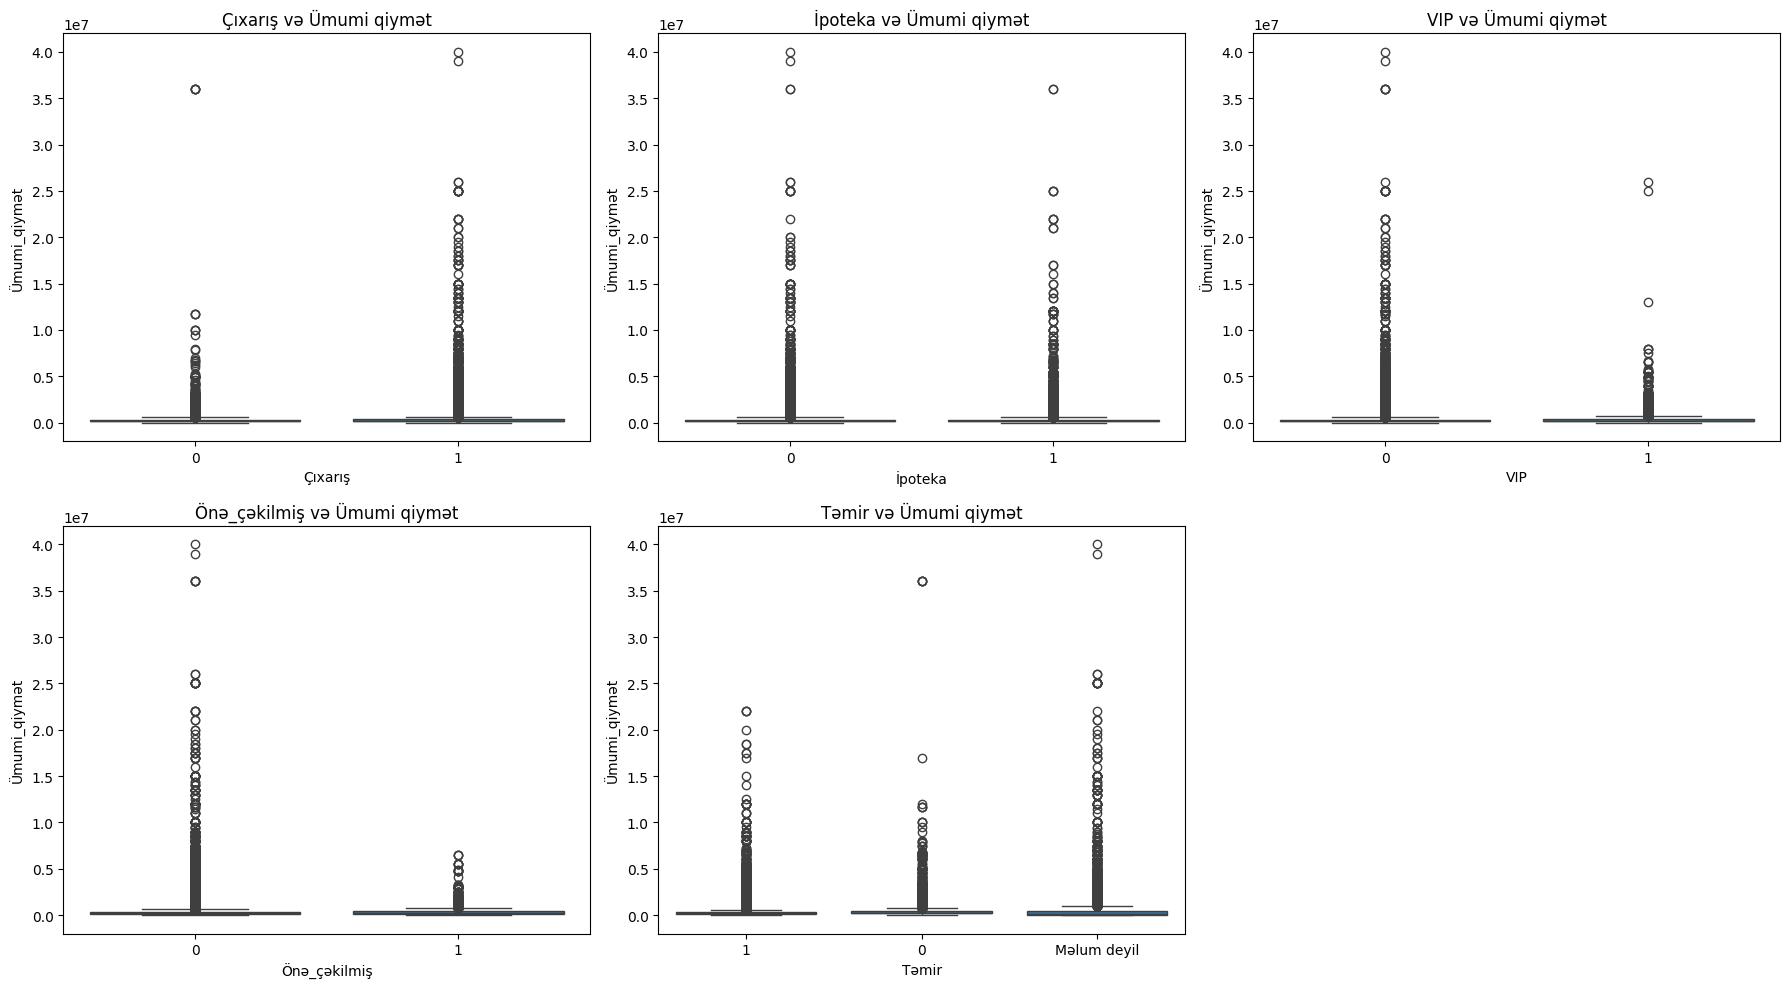

In [111]:
# Ümumi qiymətin paylanması (Boxplot)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols = ['Çıxarış', 'İpoteka', 'VIP', 'Önə_çəkilmiş', 'Təmir']

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(
        data=df,
        x=col,
        y='Ümumi_qiymət',
        ax=ax
    )
    ax.set_title(f'{col} və Ümumi qiymət')
fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()

Çıxarışı olan əmlaklarda qiymət diapazonu daha genişdir və yüksək qiymətli elanlar daha çox bu qrupa aiddir. İpoteka, VIP və önə çəkilmiş statuslarının qiymətə təsiri zəif müşahidə olunur, çünki bu xüsusiyyətlərə malik və malik olmayan elanların qiymət paylanmaları böyük ölçüdə oxşardır. Təmirli əmlakların isə ümumilikdə daha yüksək qiymətə malik olduğu görünür. Həmçinin bütün qrafiklərdə çoxsaylı outlier-lərin mövcud olması datasetdə yüksək qiymətli villa, torpaq və biznes mərkəzləri kimi əmlakların yer alması ilə izah olunur.

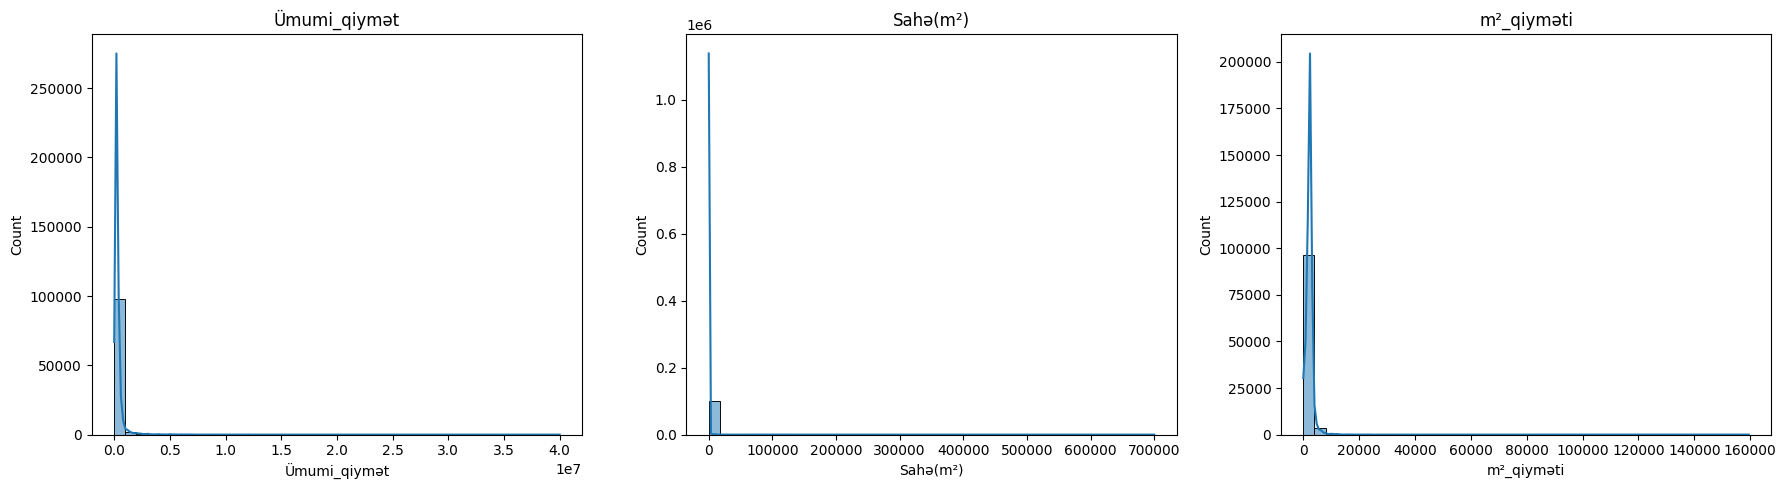

In [112]:
# Ümumi qiymət, Sahə(m²) və m² qiymətinin paylanması
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, columns):
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

Ümumi qiymət, Sahə(m²) və m² qiyməti sütunlarının paylanmaları sağa meyllidir (right-skewed). Müşahidələrin böyük hissəsi aşağı qiymətlərdə və kiçik sahələrdə cəmləşmiş, az sayda çox böyük dəyərlər isə uzun sağ quyruq (long right tail) yaratmışdır. Bu vəziyyət datasetdə çoxsaylı outlier-lərin mövcud olduğunu göstərir və məlumatların normal paylanmadığını göstərir. Buna görə də sonrakı analizdə log transformasiyası ilə normala yaxın versiyaya baxaq. Çünki əmlaklar müxtəlif kateqoriyalara aiddir və istər sahə, istərsə də qiymət baxımından fərqlənə bilir.

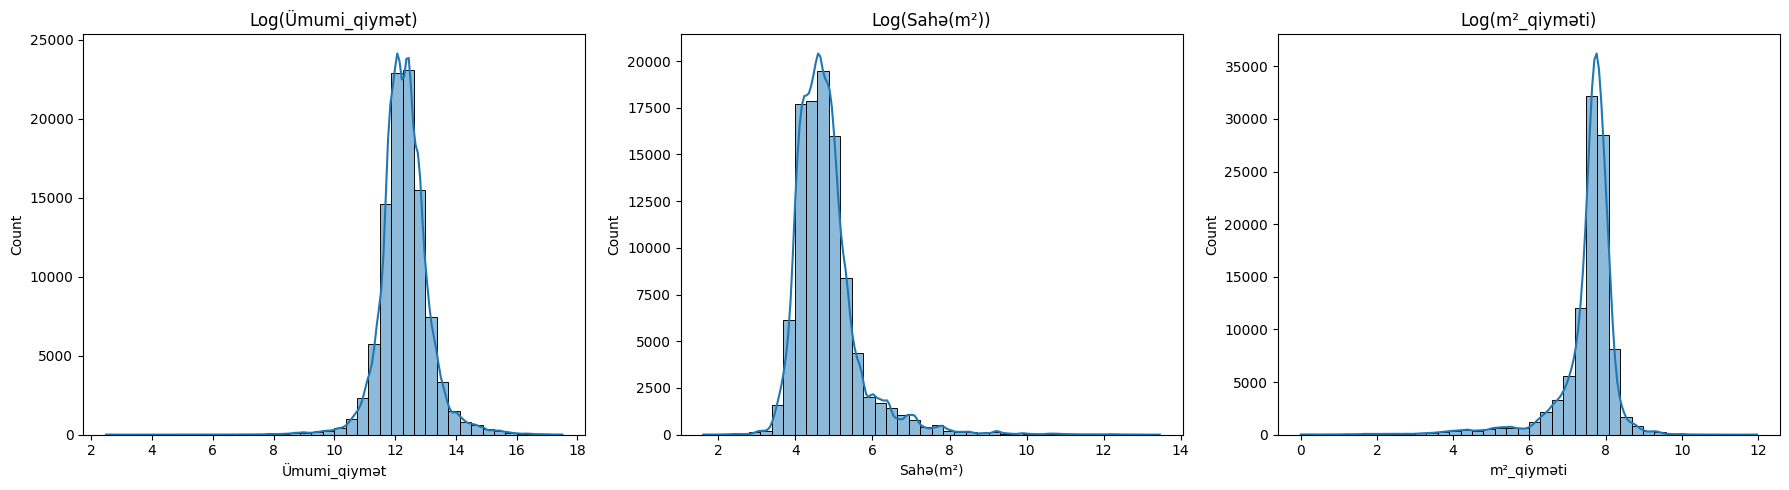

In [113]:
# Log transformasiyasından sonra Ümumi qiymət, Sahə(m²) və m² qiymətinin paylanması
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, columns):
    sns.histplot(
        np.log1p(df[col]),
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(f'Log({col})')
plt.tight_layout()
plt.show()

Log transformasiyasından sonra Ümumi qiymət, Sahə(m²) və m² qiyməti sütunlarının paylanması daha aydın görünür. Ümumi qiymət və m² qiyməti təxminən zəngvari (normala yaxın) paylanma nümayiş etdirsə də, sağ tərəfdə uzun quyruq qalmaqdadır ki, bu da yüksək qiymətli outlier-lərin hələ də mövcud olduğunu göstərir. Sahə(m²) sütunu isə daha çox sağa meyilli paylanmaya malikdir və çox böyük sahəyə sahib azsaylı əmlaklar səbəbindən sağ quyruq daha uzundur. Ümumilikdə, log transformasiyası böyük dəyərlərin təsirini azaltdığı üçün məlumatların əsas hissəsinin paylanmasını daha aydın müşahidə etməyə imkan verir.

Qeyd: Paylanmanın daha aydın görünməsi üçün histogramlarda log transformasiyası (log1p) tətbiq edilmişdir. Bu transformasiya məlumatların nisbi quruluşunu qoruyaraq yüksək outlier-lərin vizuallaşdırmaya təsirini azaldır.

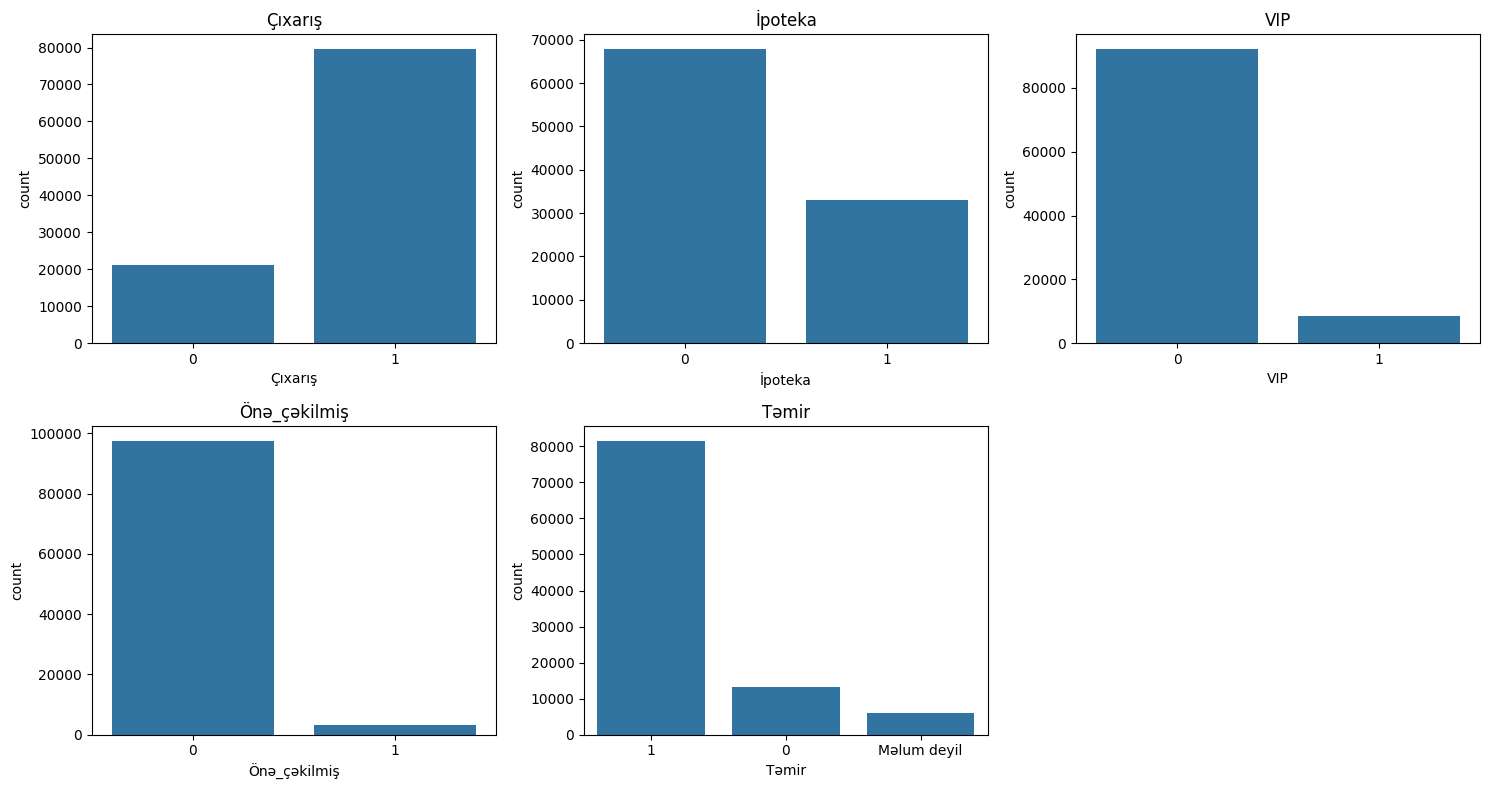

In [114]:
# Binary kateqoriyalar üzrə elan sayı
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()

Elanların böyük əksəriyyətində çıxarış və təmir mövcuddur. Əmlakların təxminən üçdə biri ipotekaya yararlıdır, lakin əksəriyyəti ipotekaya uyğun deyil. VIP və önə çəkilmiş elanların sayı isə ümumi elanlarla müqayisədə olduqca azdır. Bundan əlavə, təmir sütununda az sayda "Məlum deyil" kateqoriyası da mövcuddur.

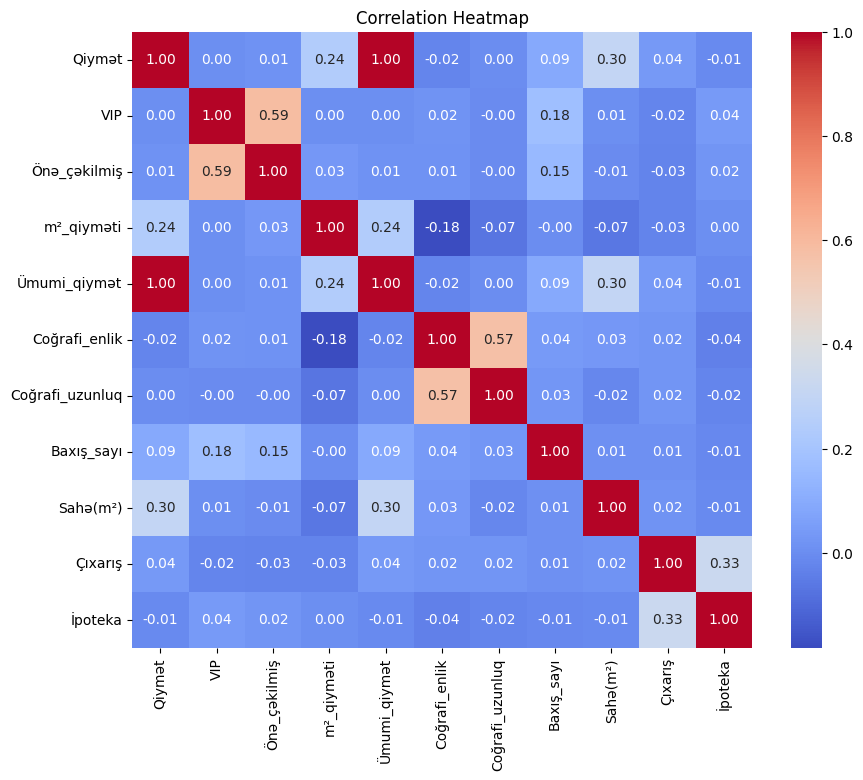

In [115]:
# Korrelyasiya heatmap
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Dəyişənlər arasında ümumilikdə güclü xətti əlaqə yoxdur. Ümumi qiymət ilə Sahə(m²) arasında zəif müsbət korrelyasiya, m² qiyməti ilə isə daha zəif müsbət korrelyasiya müşahidə olunur. Coğrafi enlik və coğrafi uzunluq arasında orta səviyyəli müsbət əlaqə mövcuddur ki, bu da onların coğrafi koordinatlar olmasından irəli gəlir. Çıxarış və İpoteka arasında da orta səviyyəli müsbət korrelyasiya müşahidə edilir və bu, ipotekaya uyğun əmlakların əksəriyyətində çıxarışın olmasını göstərir. Digər dəyişənlər arasında korrelyasiya əmsalları 0-a yaxın olduğundan onların arasında əhəmiyyətli xətti əlaqə müşahidə olunmur.

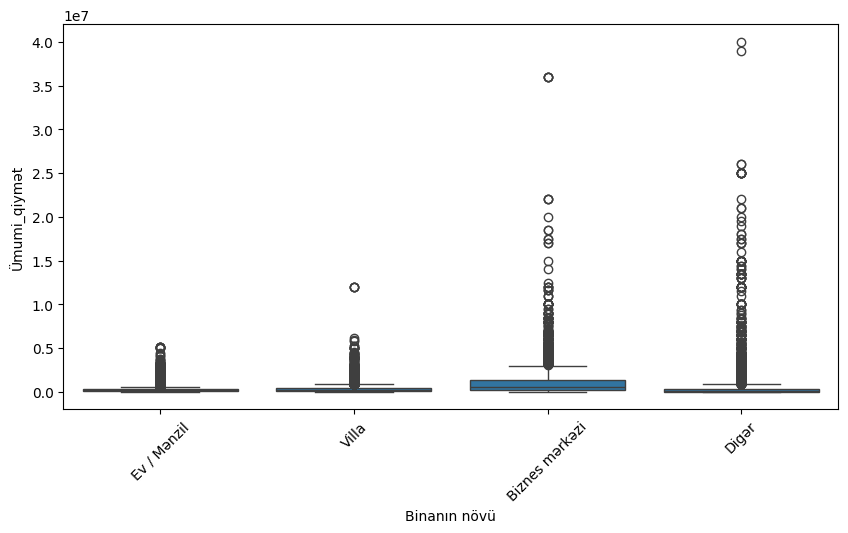

In [116]:
# Binanın növünə görə ümumi qiymətin paylanması (Boxplot)
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='Binanın növü',
    y='Ümumi_qiymət'
)
plt.xticks(rotation=45)
plt.show()

Biznes mərkəzi kateqoriyasına aid obyektlərin median qiyməti digər bina növləri ilə müqayisədə daha yüksəkdir və qiymət diapazonu daha genişdir. Ev/Mənzil və Villa kateqoriyalarında qiymətlər nisbətən aşağı və daha sıx paylanmışdır. Digər kateqoriyasında isə çoxsaylı yüksək qiymətli outlier-lər müşahidə olunur ki, bu da həmin qrupa bahalı torpaq və kommersiya obyektlərinin daxil olması ilə əlaqədardır. Ümumilikdə, bina növünün əmlakın ümumi qiymətinə təsir göstərən əsas amillərdən biri olduğu görünür.

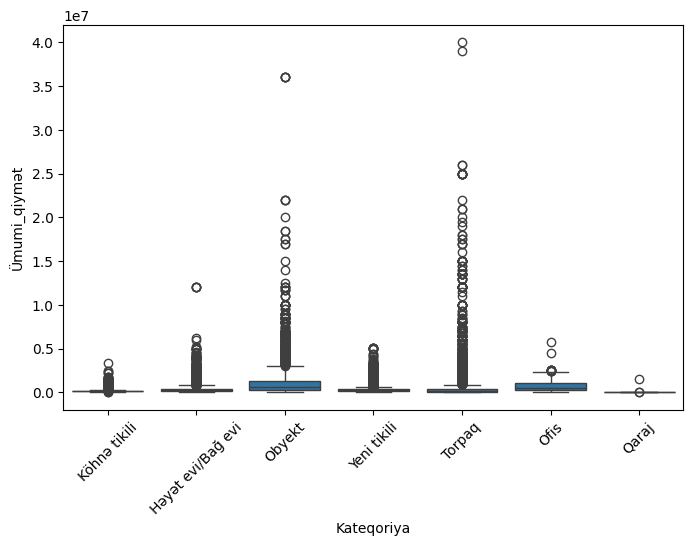

In [117]:
# Əmlak kateqoriyasına görə ümumi qiymətin paylanması (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Kateqoriya',
    y='Ümumi_qiymət'
)
plt.xticks(rotation=45)
plt.show()

Obyekt kateqoriyası digər kateqoriyalarla müqayisədə daha yüksək median qiymətə və daha geniş qiymət diapazonuna malikdir. Torpaq kateqoriyasında median qiymət aşağı olsa da, çoxlu sayda yüksək qiymətli outlier müşahidə olunur ki, bu da böyük və dəyərli torpaq sahələrinin mövcudluğu ilə izah olunur. Ofis kateqoriyasında da qiymətlər nisbətən yüksəkdir, lakin müşahidələrin sayı azdır. Köhnə tikili, Yeni tikili, Həyət evi/Bağ evi və Qaraj kateqoriyalarında qiymətlər daha aşağı diapazonda cəmlənmişdir. Ümumilikdə, əmlakın kateqoriyası onun ümumi qiymətinə əhəmiyyətli təsir göstərən amillərdən biridir.

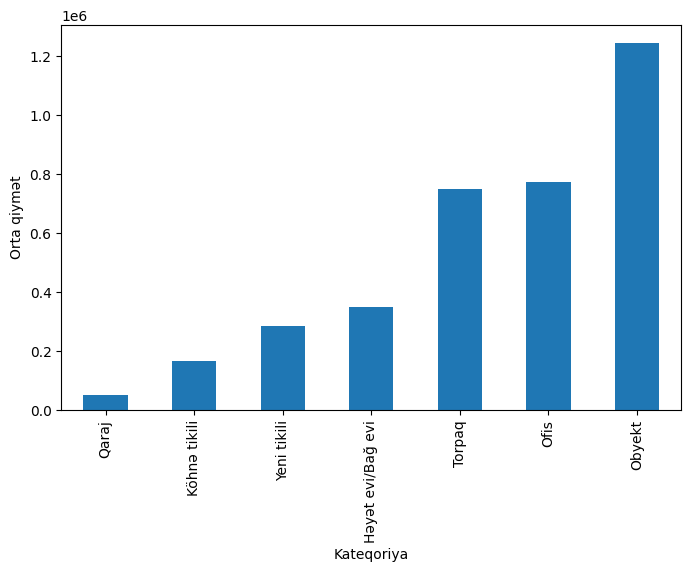

In [118]:
# Əmlak kateqoriyalarına görə orta qiymətin müqayisəsi
mean_price = (df.groupby('Kateqoriya')['Ümumi_qiymət'].mean().sort_values())

mean_price.plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Orta qiymət")
plt.show()

Obyekt kateqoriyası ən yüksək orta qiymətə malikdir. Onu Ofis və Torpaq kateqoriyaları izləyir. Həyət evi/Bağ evi və Yeni tikili kateqoriyalarının orta qiymətləri orta səviyyədədir, Köhnə tikili və xüsusilə Qaraj kateqoriyaları isə ən aşağı orta qiymətə malikdir. Ümumilikdə, kommersiya təyinatlı əmlakların yaşayış tipli əmlaklarla müqayisədə daha yüksək orta qiymətə sahib olduğu müşahidə olunur.

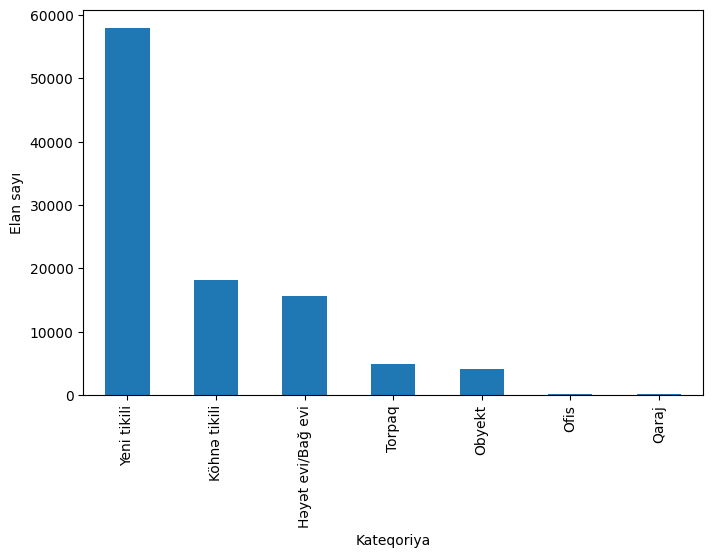

In [119]:
# Əmlak kateqoriyaları üzrə elan sayının paylanması
df['Kateqoriya'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Elan sayı")
plt.show()

Elanların böyük hissəsini Yeni tikili kateqoriyası təşkil edir. Onu Köhnə tikili və Həyət evi/Bağ evi kateqoriyaları izləyir. Torpaq və Obyekt kateqoriyalarında elan sayı nisbətən azdır, Ofis və Qaraj kateqoriyaları isə verilənlər bazasında ən az təmsil olunan kateqoriyalardır. Bu nəticə göstərir ki, bazarda ən çox təklif olunan əmlak növü yeni tikili mənzillərdir, kommersiya və digər xüsusi təyinatlı əmlaklar isə daha az sayda elanla təmsil olunur.

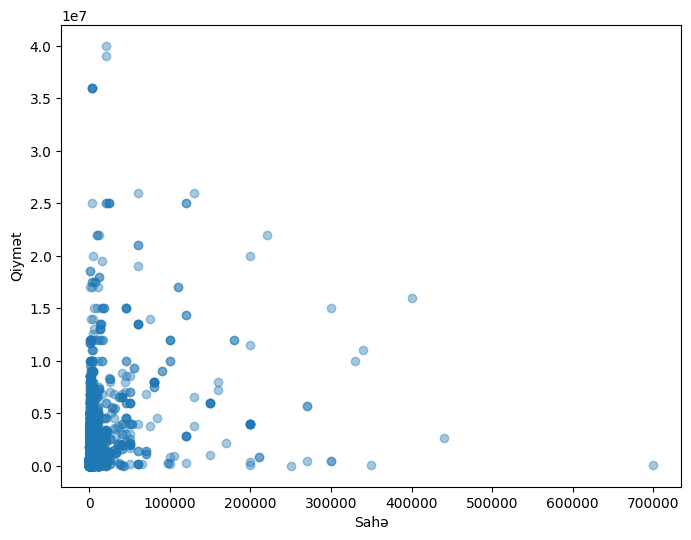

In [120]:
# Sahə ilə qiymət arasındakı əlaqə (Scatter Plot)
plt.figure(figsize=(8,6))
plt.scatter(
    df['Sahə(m²)'],
    df['Ümumi_qiymət'],
    alpha=0.4
)
plt.xlabel("Sahə")
plt.ylabel("Qiymət")
plt.show()

Sahə ilə qiymət arasında zəif müsbət əlaqə mövcuddur. Ümumilikdə sahə artdıqca qiymətin artması müşahidə olunsa da, bu əlaqə xətti deyil və verilənlər geniş şəkildə səpələnmişdir. Kiçik sahəli əmlaklarda həm aşağı, həm də çox yüksək qiymətli elanlar mövcuddur, böyük sahəli əmlaklarda isə nümunə sayı azdır və bir neçə ekstremal qiymət diqqət çəkir. Bu da göstərir ki, əmlakın qiyməti yalnız sahədən deyil, yerləşdiyi məkan, kateqoriya, bina növü və digər xüsusiyyətlərdən də əhəmiyyətli dərəcədə asılıdır.

# Nəticə

Ümumi qiymət, sahə (m²) və m² qiyməti dəyişənləri sağa meylli (right-skewed) paylanmaya malikdir. Müşahidələrin böyük hissəsi nisbətən aşağı qiymət və kiçik sahəli əmlaklardan ibarət olsa da, az sayda çox yüksək qiymətli və geniş sahəli əmlaklar paylanmanın sağ quyruğunu uzadır və çoxsaylı outlier-lərin yaranmasına səbəb olur. Korrelyasiya analizi göstərdi ki, ümumi qiymətlə sahə arasında zəif müsbət əlaqə (≈0.30), ümumi qiymətlə m² qiyməti arasında isə zəif müsbət əlaqə (≈0.24) mövcuddur. Bu nəticə göstərir ki, sahənin artması qiymətə müəyyən təsir göstərsə də, əmlakın dəyəri yalnız sahə ilə izah edilə bilməz. Scatter plot da bunu təsdiqləyir ki, eyni sahəyə malik əmlaklar arasında qiymət fərqləri kifayət qədər böyükdür. Bu isə qiymətə məkan, əmlak kateqoriyası, bina növü, təmir vəziyyəti, çıxarış və digər xüsusiyyətlərin də əhəmiyyətli təsir göstərdiyini göstərir. Boxplot və barplot qrafikləri əsasında obyekt və ofis kimi kommersiya təyinatlı əmlakların orta qiymətlərinin yaşayış tipli əmlaklardan daha yüksək olduğu, torpaq kateqoriyasında isə çoxsaylı yüksək qiymətli outlier-lərin mövcud olduğu müəyyən edilmişdir. Bundan əlavə, kateqoriyalar üzrə elan sayı analizində yeni tikili mənzillərin bazarda üstünlük təşkil etdiyi, ofis və qaraj kimi kateqoriyaların isə ümumi elanlar arasında çox kiçik paya malik olduğu müşahidə edilmişdir. Bu nəticələr göstərir ki, əmlak bazarında qiymətlərin formalaşmasına bir neçə amil birlikdə təsir edir və daha dəqiq proqnozlaşdırma üçün müxtəlif xüsusiyyətlərin eyni vaxtda nəzərə alınması vacibdir.